---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** __장다예__ &nbsp; **학번:** ____20251281____ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. cancer.xlsx의 Data 시트 불러오기
df = pd.read_excel('cancer.xlsx', sheet_name='Data')
df.head()

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Endpoint,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,cancer_4298,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Weakly Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
1,cancer_4297,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
2,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Top dose,15,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
3,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Level of evidence of carcinogenic activity,Clear evidence,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
4,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026


In [27]:
# 데이터 내 존재하는 종(Species)의 분포 확인
df['Species'].value_counts()

Species
Mouse      3286
Rat        2905
Hamster      20
Name: count, dtype: int64

In [28]:
# Mouse 실험 결과+Chemical만 선택
df_m = df[(df['Species'] == 'Mouse') & (df['Mixture'] == 'Chemical')].copy()
df_m.head()

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Endpoint,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,cancer_4298,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Weakly Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
1,cancer_4297,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
4,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
5,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Level of evidence of carcinogenic activity,Inadequate experiment,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
6,cancer_3381,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026


In [29]:
# 마우스 데이터 내에 존재하는 Endpoint 종류 및 빈도 확인
df_m['Endpoint'].value_counts()

Endpoint
Top dose                                      1100
Level of evidence of carcinogenic activity    1098
Micronucleus                                   612
POLY-3 lowest dose                             321
Comet assay                                     25
Name: count, dtype: int64

In [30]:
#'Level of evidence of carcinogenic activity(발암성 평가 결과)'를 가진 데이터 추출
df_evi = df_m[df_m['Endpoint'] == 'Level of evidence of carcinogenic activity'].copy()

# 불확실한 결과(Equivocal, Inadequate, Not tested 등) 제거
valid_responses = ['Clear evidence', 'Some evidence', 'No evidence']
df_evi = df_evi[df_evi['Response'].isin(valid_responses)].copy()
df_evi.shape

(897, 28)

In [31]:
# 필터링된 최종 발암성 응답 값들의 분포 확인
df_evi['Response'].value_counts()

Response
No evidence       516
Clear evidence    320
Some evidence      61
Name: count, dtype: int64

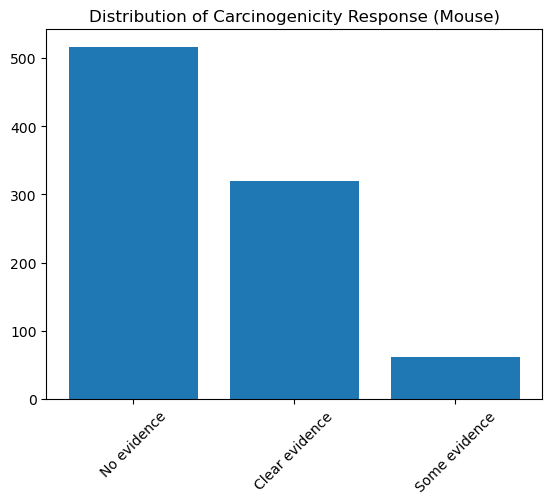

In [32]:
# 응답(Response) 값 분포 시각화
import matplotlib.pyplot as plt
evi_value = df_evi['Response'].value_counts()
plt.bar(evi_value.index, evi_value)
plt.xticks(rotation=45)
plt.title('Distribution of Carcinogenicity Response (Mouse)')
plt.show()

In [33]:
# 데이터 칼럼 확인
df_evi.columns

Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Mixture', 'Species', 'Sex', 'Strain', 'Route', 'Level_of_Evidence',
       'Tissue', 'Location', 'Lesion', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name',
       'Synonyms', 'URL_CompTox', 'URL_CEBS'],
      dtype='str')

In [34]:
# 타겟 변수 이진 라벨링 ('Clear evidence', 'Some evidence'(발암성 있음) = 1, 'No evidence'(발암성 없음) = 0)
df_evi['label'] = 0
df_evi.loc[df_evi['Response'].isin(['Clear evidence', 'Some evidence']),'label'] = 1

df_evi['label'].value_counts()

label
0    516
1    381
Name: count, dtype: int64

In [35]:
label_count = df_evi.groupby('SMILES')['label'].nunique()
label_count.head()

SMILES
*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|                        1
BrC(Br)Br                                                      1
BrC(Br)C#N                                                     1
BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2Br)C(Br)=C1Br    1
BrCC(Br)(CCC#N)C#N                                             1
Name: label, dtype: int64

In [36]:
len(label_count[label_count > 1])

51

In [40]:
conflict_smiles = label_count[label_count > 1].index
df_conflict = df_evi[df_evi['SMILES'].isin(conflict_smiles)]
df_conflict.shape

(113, 29)

In [41]:
df_conflict[['SMILES','Sex','label']].head(20)

,SMILES,Sex,label
24,CC(=O)OCC1=CC=CC=C1,Male,1
27,CC(=O)OCC1=CC=CC=C1,Female,1
33,CC(=O)OCC1=CC=CC=C1,Female,0
37,CC(=O)OCC1=CC=CC=C1,Male,0
57,NC1=CC(N)=C(Cl)C=C1,Male,0
61,NC1=CC(N)=C(Cl)C=C1,Female,1
529,CCCCC(CC)COP(=O)(OCC(CC)CCCC)OCC(CC)CCCC,Female,1
531,CCCCC(CC)COP(=O)(OCC(CC)CCCC)OCC(CC)CCCC,Male,0
687,"C*.O=C=NC1=CC(=CC=C1)N=C=O |c:6,8,t:4,lp:2:2,4...",Female,1
689,"C*.O=C=NC1=CC(=CC=C1)N=C=O |c:6,8,t:4,lp:2:2,4...",Male,0


In [43]:
smiles = 'CC(=O)OCC1=CC=CC=C1'

df_evi[df_evi['SMILES'] == smiles][['SMILES','Sex','Route','label']]

,SMILES,Sex,Route,label
24,CC(=O)OCC1=CC=CC=C1,Male,Gavage,1
27,CC(=O)OCC1=CC=CC=C1,Female,Gavage,1
33,CC(=O)OCC1=CC=CC=C1,Female,Dosed feed,0
37,CC(=O)OCC1=CC=CC=C1,Male,Dosed feed,0


In [44]:
df_evi['Route'].value_counts()

Route
Dosed feed                   334
Gavage                       218
Inhalation                   109
Dermal                        39
Dosed drinking water          35
Intraperitoneal injection     11
Gavage; Dosed feed             4
Transplacental                 3
Dosed feed; Dermal             2
Intravaginal                   1
Name: count, dtype: int64

In [11]:
valid_smiles = label_count[label_count == 1].index
df_evi = df_evi[df_evi['SMILES'].isin(valid_smiles)]
df_evi = df_evi.drop_duplicates(subset='SMILES')
df_evi = df_evi.drop(columns=['Sex'])
print(df_evi.shape)

(395, 28)


In [12]:
df_evi.to_csv('cancer_evi.csv')

In [14]:
from rdkit import Chem

df_evi['mol'] = df_evi['SMILES'].apply(Chem.MolFromSmiles)

df_evi.columns

Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Mixture', 'Species', 'Strain', 'Route', 'Level_of_Evidence', 'Tissue',
       'Location', 'Lesion', 'Assay', 'Endpoint', 'Response', 'Response_Unit',
       'Reference', 'URL', 'SMILES', 'Preferred_Name', 'Synonyms',
       'URL_CompTox', 'URL_CEBS', 'label', 'mol'],
      dtype='str')

In [16]:
import pandas as pd
from rdkit.Chem import Descriptors

descrs = []

for mol in df_evi['mol']:
    calc = Descriptors.CalcMolDescriptors(mol)
    descrs.append(calc)

df_descrs = pd.DataFrame(descrs)

df_ml = pd.concat(
    [df_evi[['SMILES', 'label']].reset_index(drop=True),
     df_descrs.reset_index(drop=True)],
    axis=1
)

print(df_ml.shape)

df_ml.head()

(395, 219)


,SMILES,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,OS(O)(=O)=O.NC1=CC=C(N)C(Cl)=C1,0,8.743056,8.743056,0.509259,-4.666667,0.393328,10.214286,240.668,231.596,...,0,0,0,0,0,0,0,0,0,0
1,CC1=C(Cl)C=C(N)C=C1,0,5.733951,5.733951,0.713519,0.713519,0.551296,9.555556,141.601,133.537,...,0,0,0,0,0,0,0,0,0,0
2,Cl.CC1=C(N)C=CC(Cl)=C1,1,5.661389,5.661389,0.000000,0.000000,0.606856,8.600000,178.062,168.990,...,0,0,0,0,0,0,0,0,0,0
3,CN(C)C(=O)NC1=CC=C(Cl)C=C1,0,11.178982,11.178982,0.150627,-0.150627,0.738802,9.461538,198.653,187.565,...,0,0,0,0,0,0,0,0,0,1
4,[O-][N+](=O)C(Cl)(Cl)Cl,0,9.430556,9.430556,1.016204,-2.361111,0.236106,11.285714,164.375,164.375,...,0,0,0,0,0,0,0,0,0,0


In [17]:
X = df_ml.drop(columns=['SMILES', 'label', 'mol'], errors='ignore')
y = df_ml['label']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.81      0.72        47
           1       0.57      0.38      0.45        32

    accuracy                           0.63        79
   macro avg       0.61      0.59      0.59        79
weighted avg       0.62      0.63      0.61        79



In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

importance.sort_values(
    by='importance',
    ascending=False
).head(20)